In [1]:
import arviz as az
import bayesflow as bf
import blackjax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from confrdm.data import load_hdf5
from confrdm_jax.plots import  plot_data_hist

INFO:2026-02-06 11:04:15,663:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## RDM

In [2]:
def reshape_posterior_samples(samples):
    return np.reshape(samples, (samples.shape[0], -1, samples.shape[-1]))

In [4]:
param_names = ["v_intercept", "v_slope", "s_true", "b", "t0"]

results = load_hdf5("../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/parameter_recovery.hdf5")
posterior_samples_chains_approx = results["samples_approx"]
posterior_samples_approx = reshape_posterior_samples(posterior_samples_chains_approx)

posterior_samples_chains_ref = results["samples_ref"]
posterior_samples_ref = reshape_posterior_samples(posterior_samples_chains_ref)

prior_samples = results["true_params"]
data = results["data"]

In [5]:
posterior_samples_chains_approx.shape

(50, 1000, 4, 5)

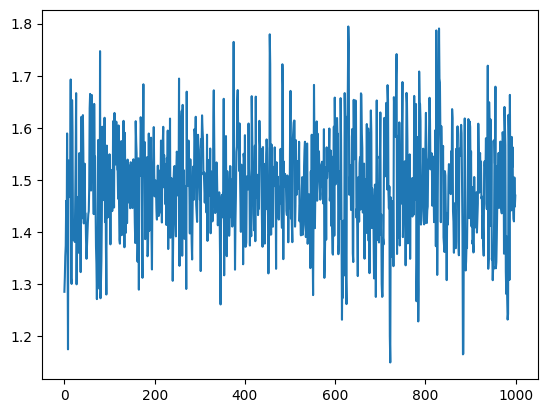

In [6]:
plt.plot(posterior_samples_chains_approx[0, :, 0, 1])

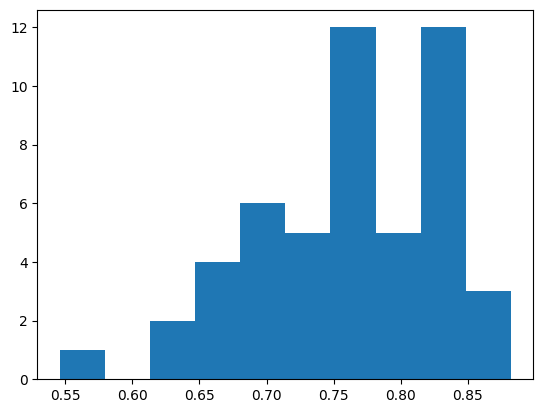

In [7]:
plt.hist(data[..., 1].mean(axis=1));

In [8]:
psrf_approx = blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains_approx, chain_axis=2, sample_axis=1)
is_converged_approx = np.all(np.isfinite(psrf_approx) & (psrf_approx < 1.01), axis=1)
is_converged_approx.mean()

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/blackjax/diagnostics.py:72: RuntimeWarning: invalid value encountered in divide
  (between_chain_variance / within_chain_variance + num_samples - 1)


Array(0.96, dtype=float32)

In [9]:
psrf_ref = blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains_ref, chain_axis=2, sample_axis=1)
is_converged_ref = np.all(np.isfinite(psrf_ref) & (psrf_ref < 1.01), axis=1)
is_converged_ref.mean()

Array(0.94, dtype=float32)

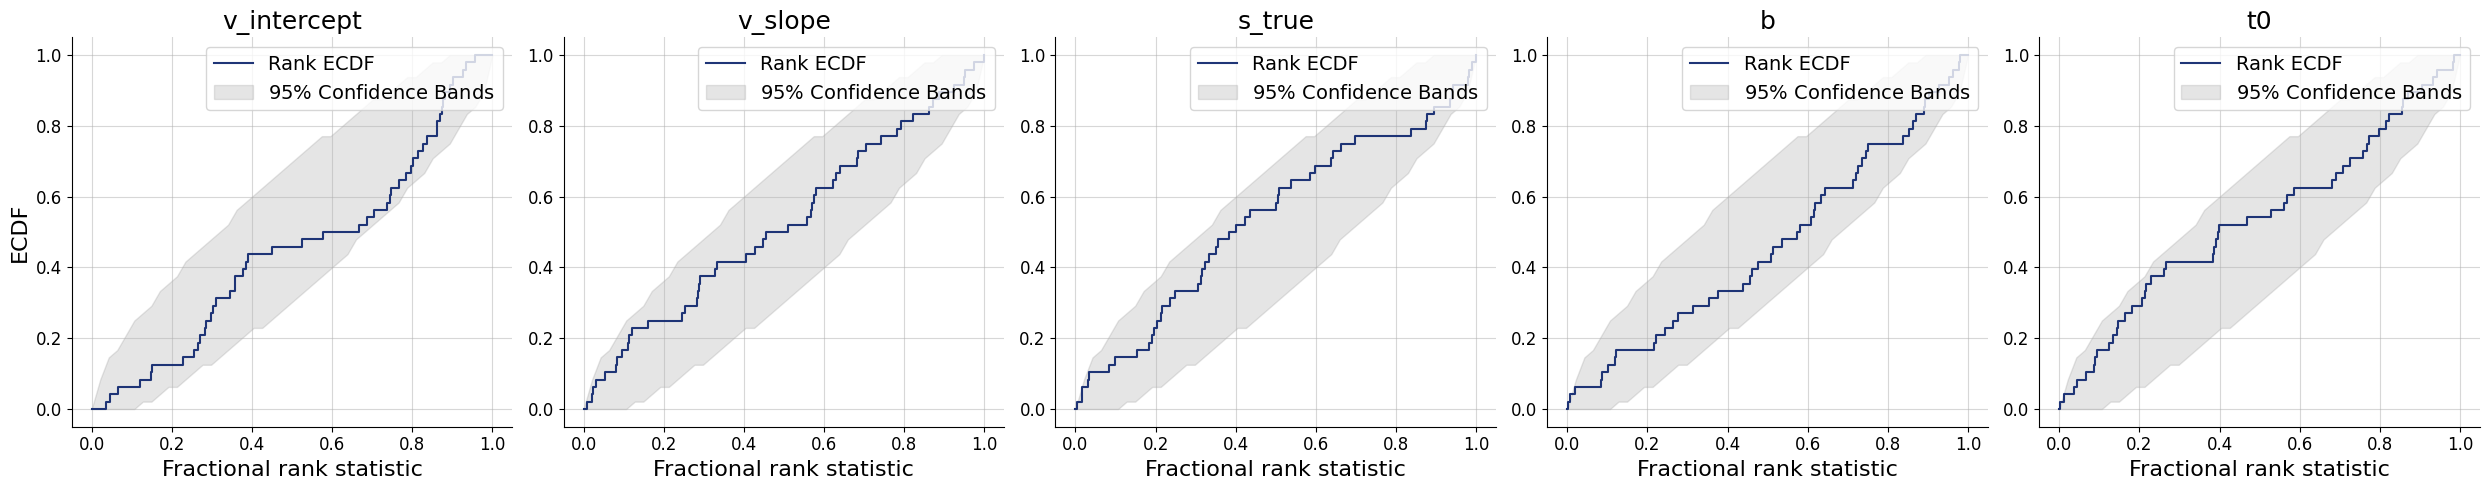

In [11]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names)
plt.savefig("parameter_recovery/rdm_ecdf_approx.png")

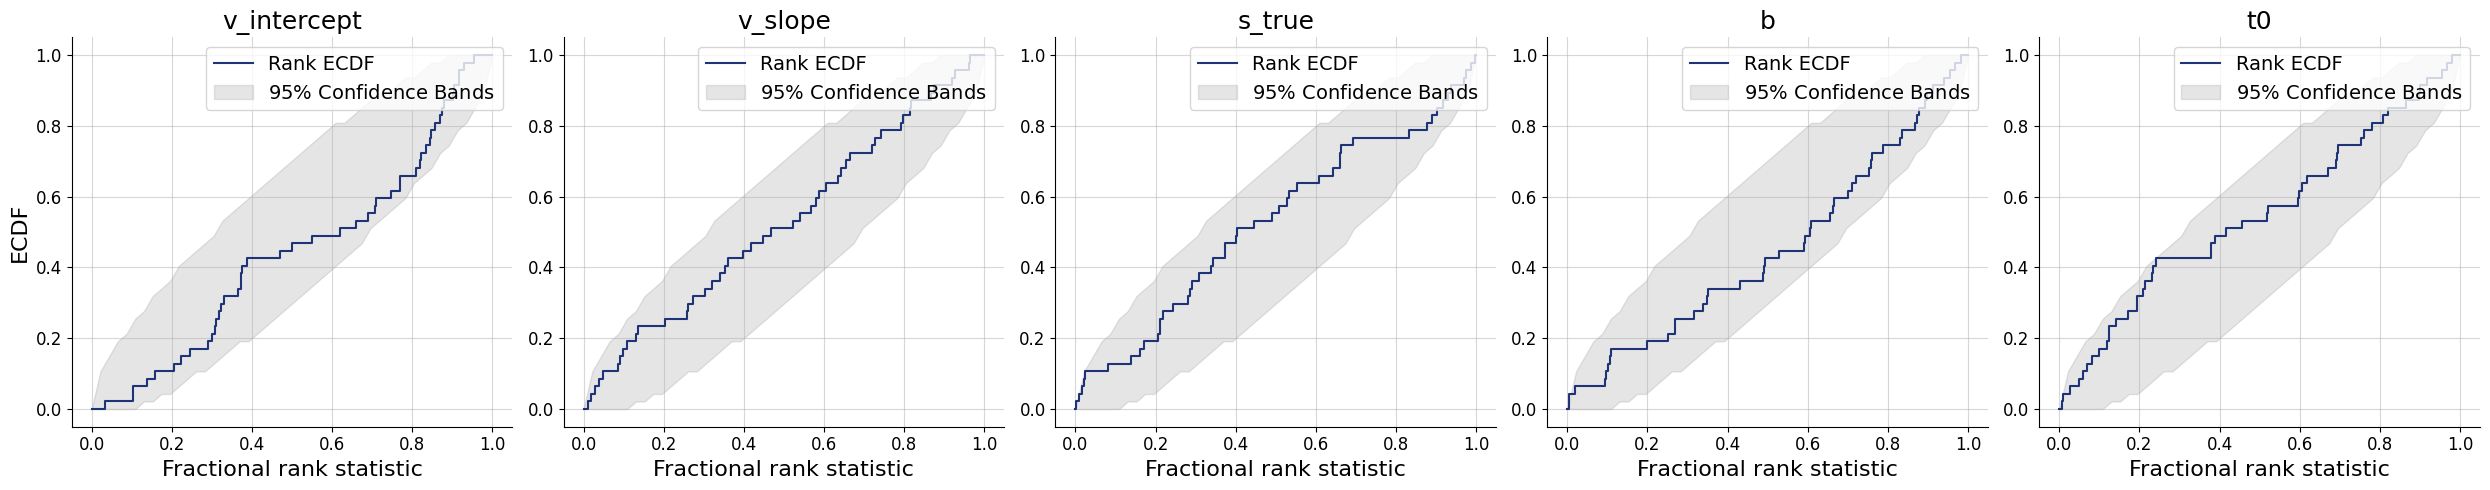

In [12]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples_ref[is_converged_ref], prior_samples[is_converged_ref], variable_names=param_names)
plt.savefig("parameter_recovery/rdm_ecdf_ref.png")

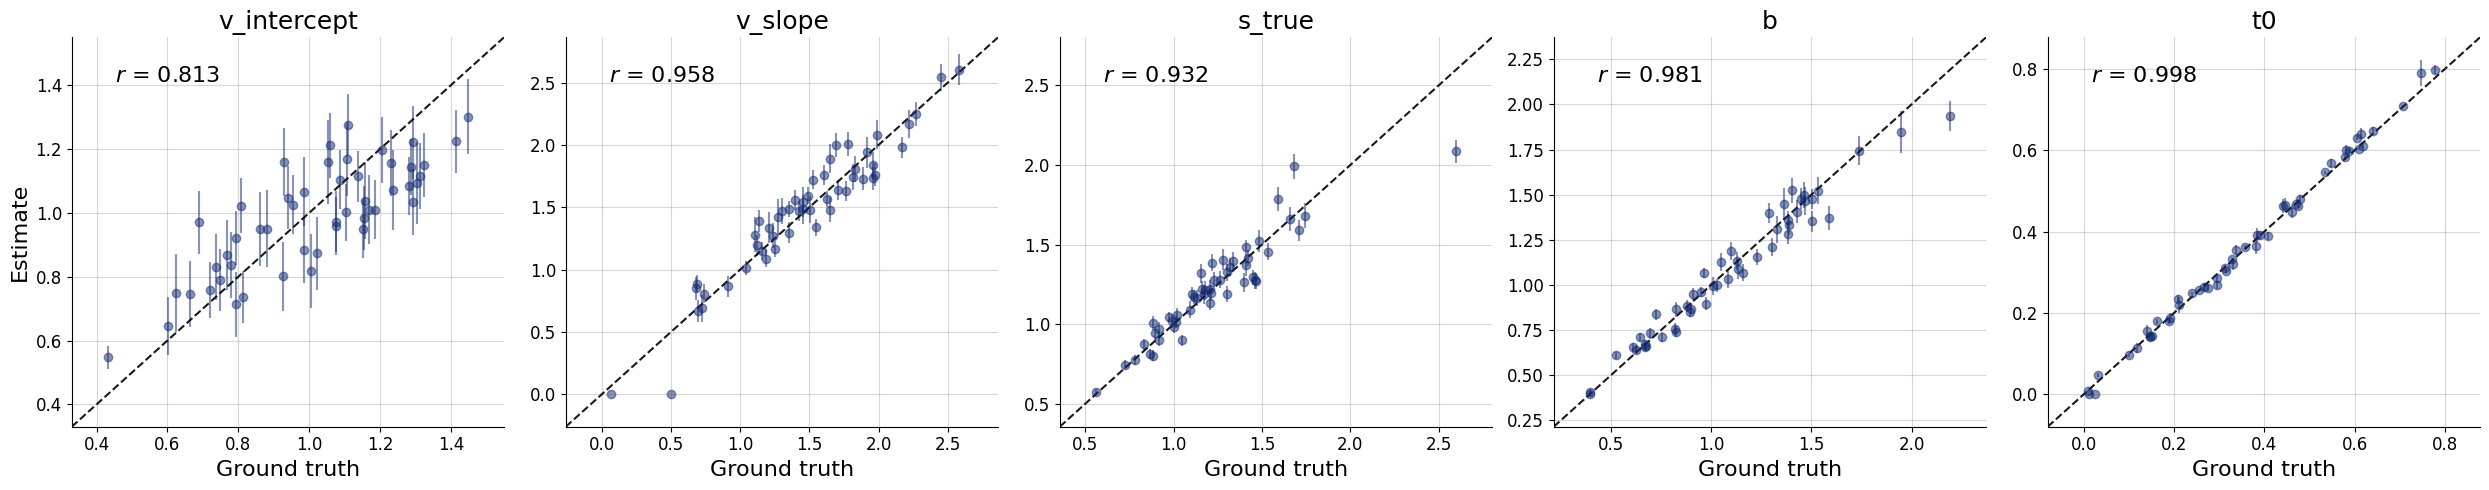

In [13]:
_ = bf.diagnostics.recovery(posterior_samples_approx, prior_samples, variable_names=param_names)
plt.savefig("parameter_recovery/rdm_recovery_approx.png")

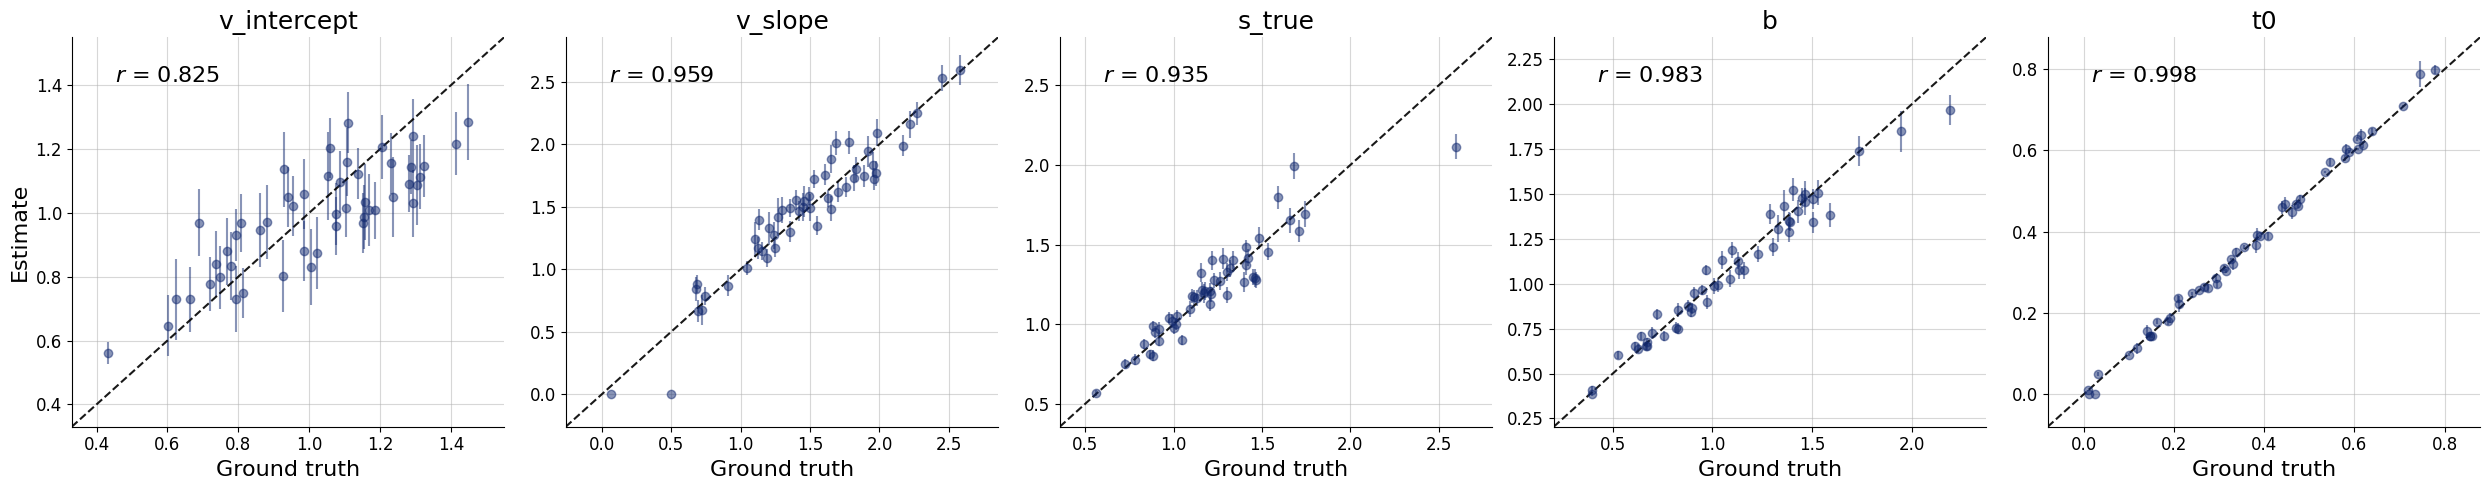

In [14]:
_ = bf.diagnostics.recovery(posterior_samples_ref, prior_samples, variable_names=param_names)
plt.savefig("parameter_recovery/rdm_recovery_ref.png")

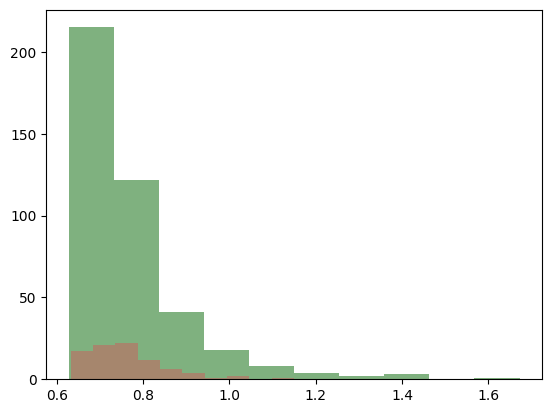

In [15]:
plot_data_hist(data[2]);

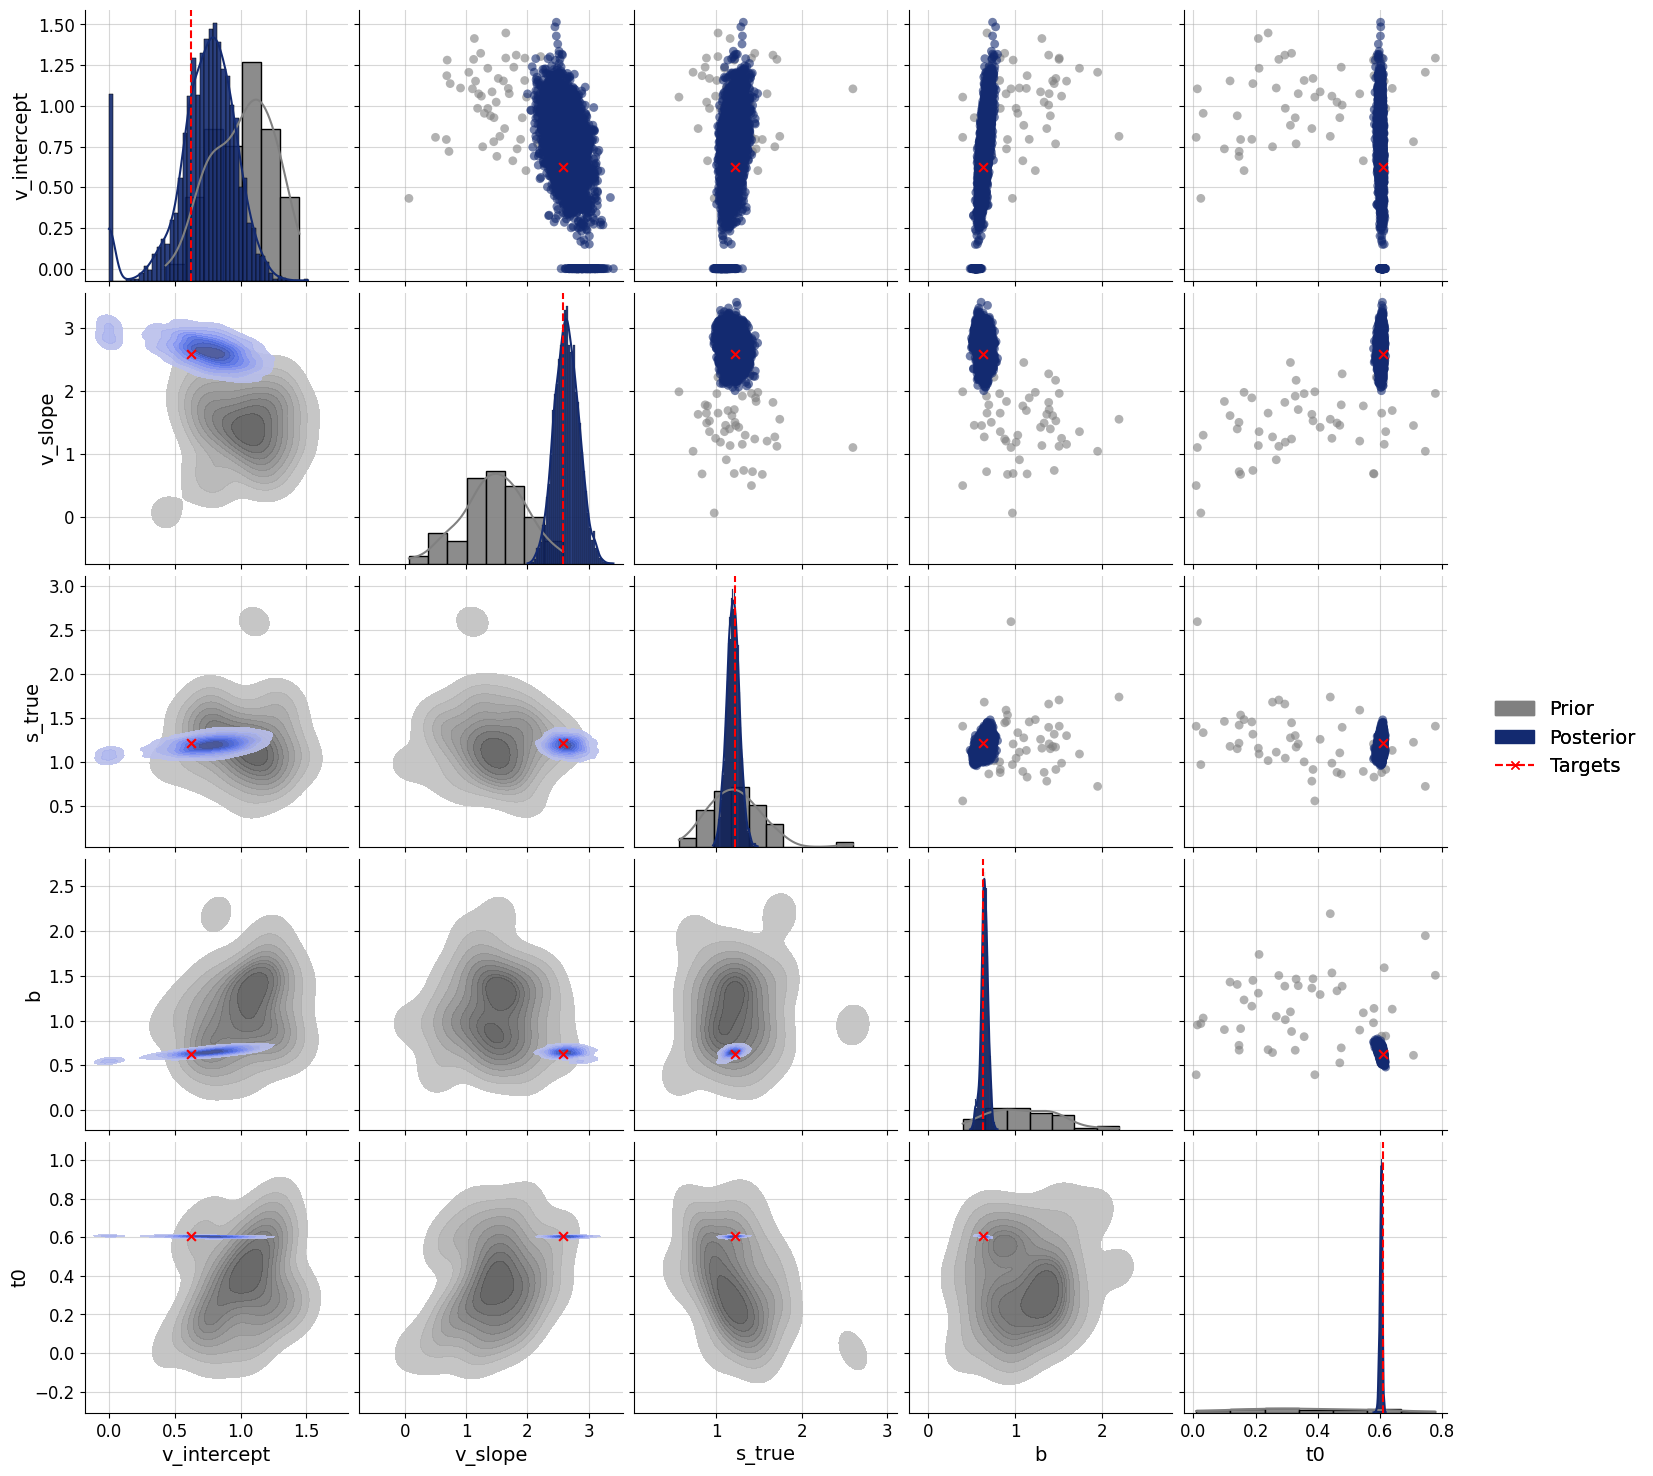

In [ ]:
_ = bf.diagnostics.pairs_posterior(posterior_samples_approx[2], prior_samples[2], prior_samples, variable_names=param_names)

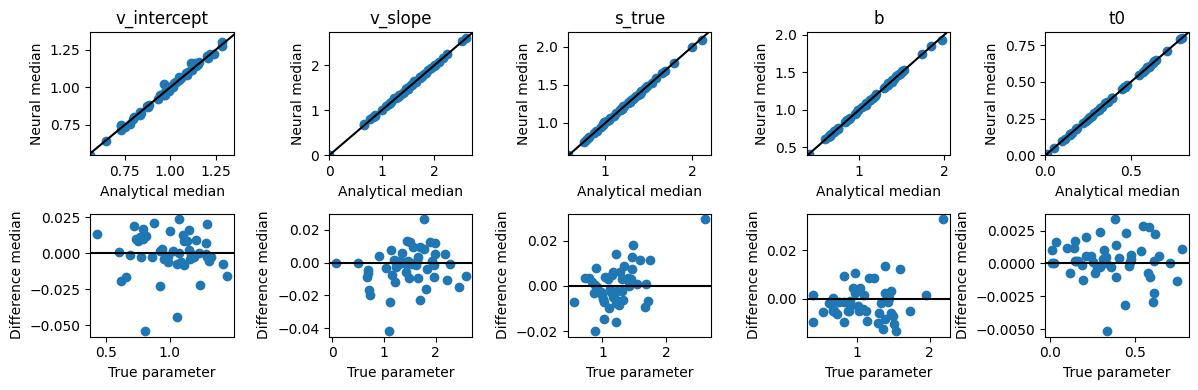

In [16]:
posterior_median_approx = np.median(posterior_samples_approx, axis=1)
posterior_median_ref = np.median(posterior_samples_ref, axis=1)

fig, axarr = plt.subplots(2, 5, figsize=(12, 4))

for i, param in enumerate(param_names):
    axarr[0, i].scatter(posterior_median_ref[:, i], posterior_median_approx[:, i])
    axarr[0, i].axline((0, 0), slope=1.0, color="black")
    axarr[0, i].set_xlim((posterior_median_ref[:, i].min(), None))
    axarr[0, i].set_ylim((posterior_median_approx[:, i].min(), None))
    axarr[0, i].set_xlabel("Analytical median")
    axarr[0, i].set_ylabel("Neural median")
    axarr[0, i].set_title(param)

    axarr[1, i].scatter(prior_samples[:, i], posterior_median_ref[:, i] - posterior_median_approx[:, i])
    axarr[1, i].axhline(color="black")
    axarr[1, i].set_xlabel("True parameter")
    axarr[1, i].set_ylabel("Difference median")

fig.tight_layout()
plt.savefig("parameter_recovery/rdm_diff_approx_ref.png")

## CRDM

In [44]:
param_names = ["v_c_intercept", "v_c_slope", "amp", "tau", "s_true", "b", "t0"]

results = load_hdf5("../outputs/crdm/model.num_bins=12/model.num_mid=128/model.recovery_prior.v_c_slope_loc=2.5/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/parameter_recovery.hdf5")
posterior_samples_chains_approx = results["samples_approx"]
posterior_samples_approx = reshape_posterior_samples(posterior_samples_chains_approx)

prior_samples = results["true_params"]
data = results["data"]

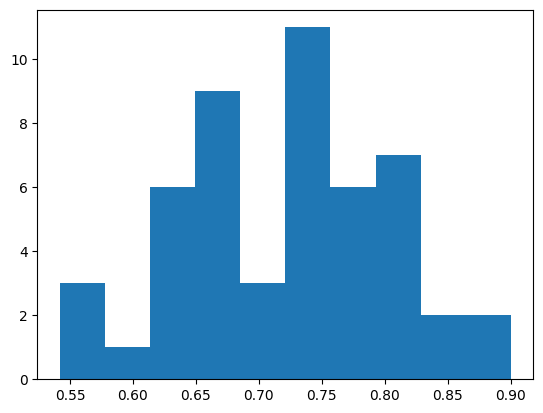

In [45]:
plt.hist(data[..., 1].mean(axis=1));

In [46]:
psrf_approx = blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains_approx, chain_axis=2, sample_axis=1)
is_converged_approx = np.all(np.isfinite(psrf_approx) & (psrf_approx < 1.01), axis=1)
is_converged_approx.mean()

Array(0.88, dtype=float32)

In [47]:
psrf_approx

Array([[1.0012648 , 1.0002162 , 1.0000951 , 0.9999478 , 0.9996431 ,
        1.0009606 , 1.0018787 ],
       [1.0058153 , 1.0035218 , 0.9995619 , 1.0016972 , 1.0012101 ,
        1.0033916 , 1.0019041 ],
       [1.0010123 , 1.0009402 , 1.0005481 , 1.0010662 , 1.0005109 ,
        1.0009654 , 0.9997629 ],
       [0.9996064 , 1.0000724 , 1.0001343 , 1.0002491 , 0.9995363 ,
        1.0006777 , 1.0003375 ],
       [1.001724  , 1.000009  , 1.0000921 , 1.0003682 , 1.0014436 ,
        1.0004066 , 0.9997543 ],
       [1.0033072 , 1.0003291 , 1.0000656 , 1.0007056 , 1.0002683 ,
        1.0020759 , 1.0003532 ],
       [0.99993426, 0.99963385, 1.0001099 , 0.99989957, 1.0013363 ,
        1.0004722 , 1.0035629 ],
       [1.0004483 , 1.001386  , 0.9996313 , 0.99968415, 0.99978745,
        0.99970657, 1.0000505 ],
       [1.0002888 , 1.0007997 , 1.0024366 , 1.0007311 , 0.99978566,
        1.0015407 , 1.0007551 ],
       [1.0015603 , 1.0029871 , 1.0000606 , 1.0012047 , 0.9998967 ,
        1.0007248 , 1.0

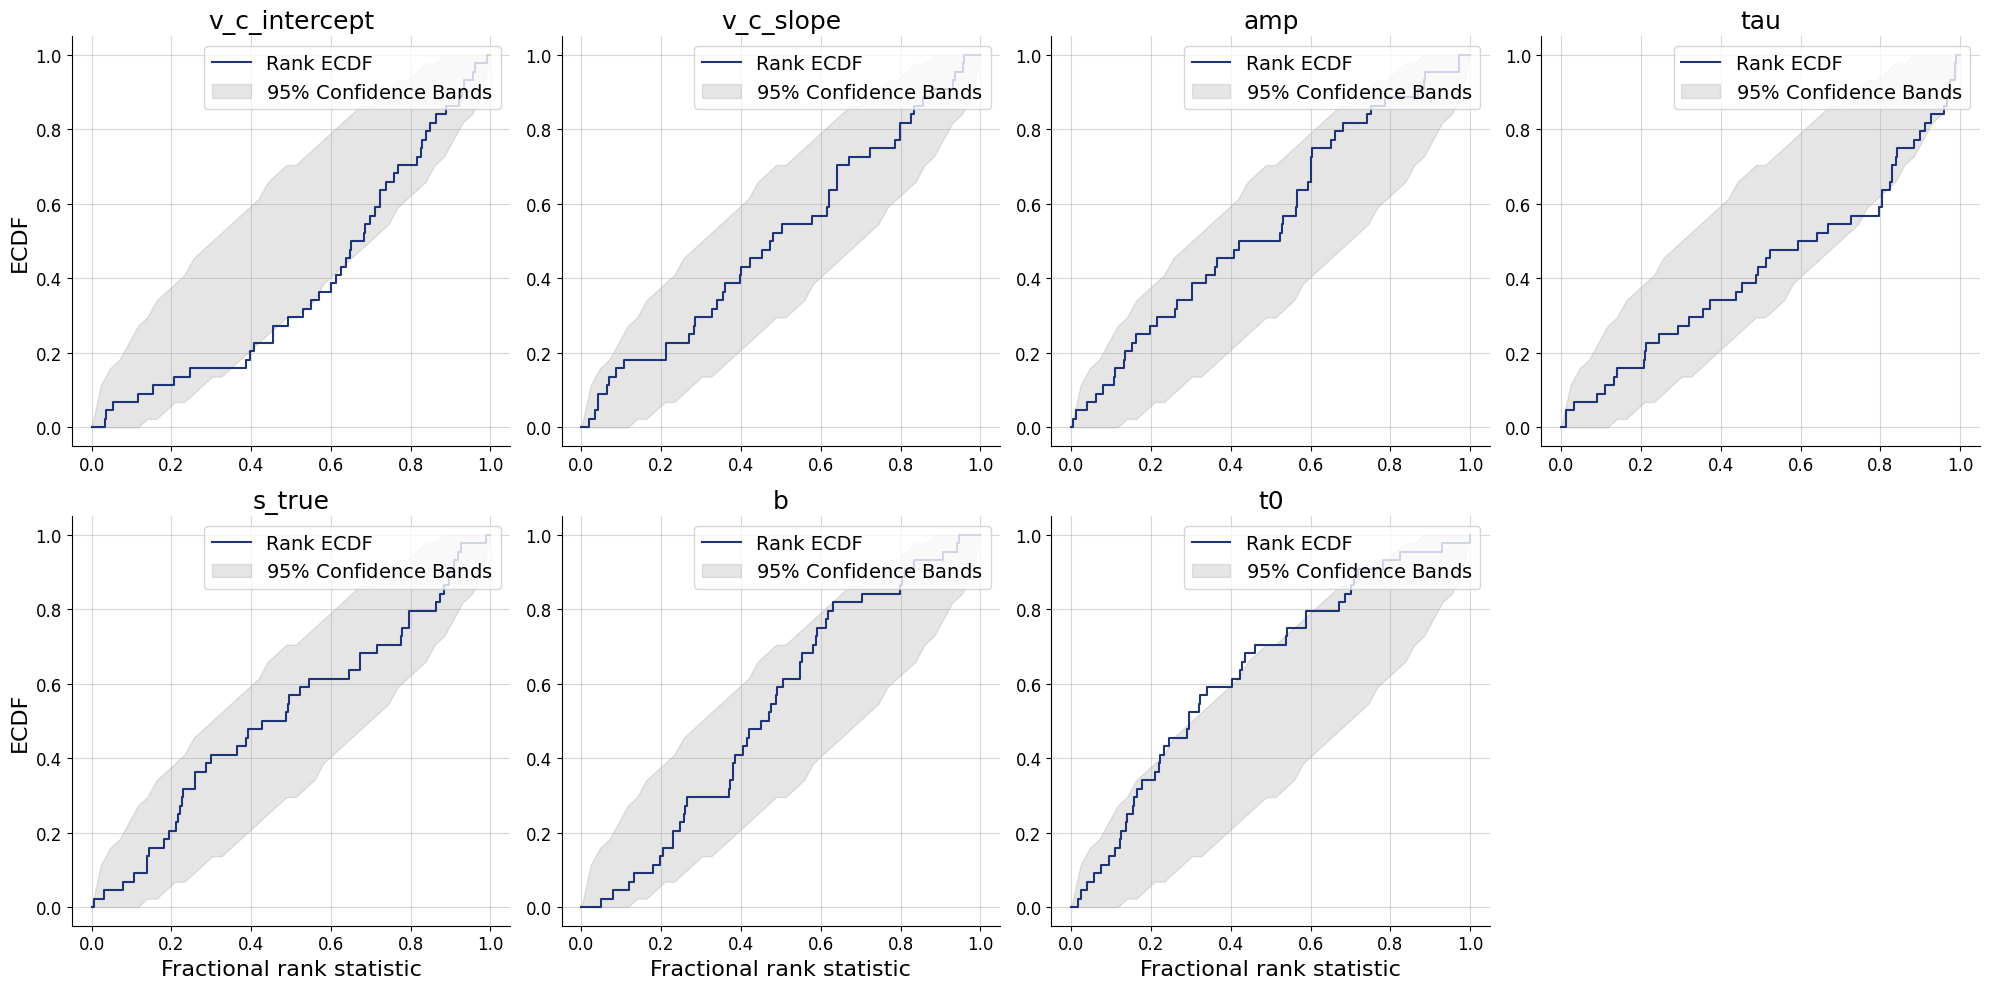

In [48]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names)
plt.savefig("parameter_recovery/crdm_ecdf_approx.png")

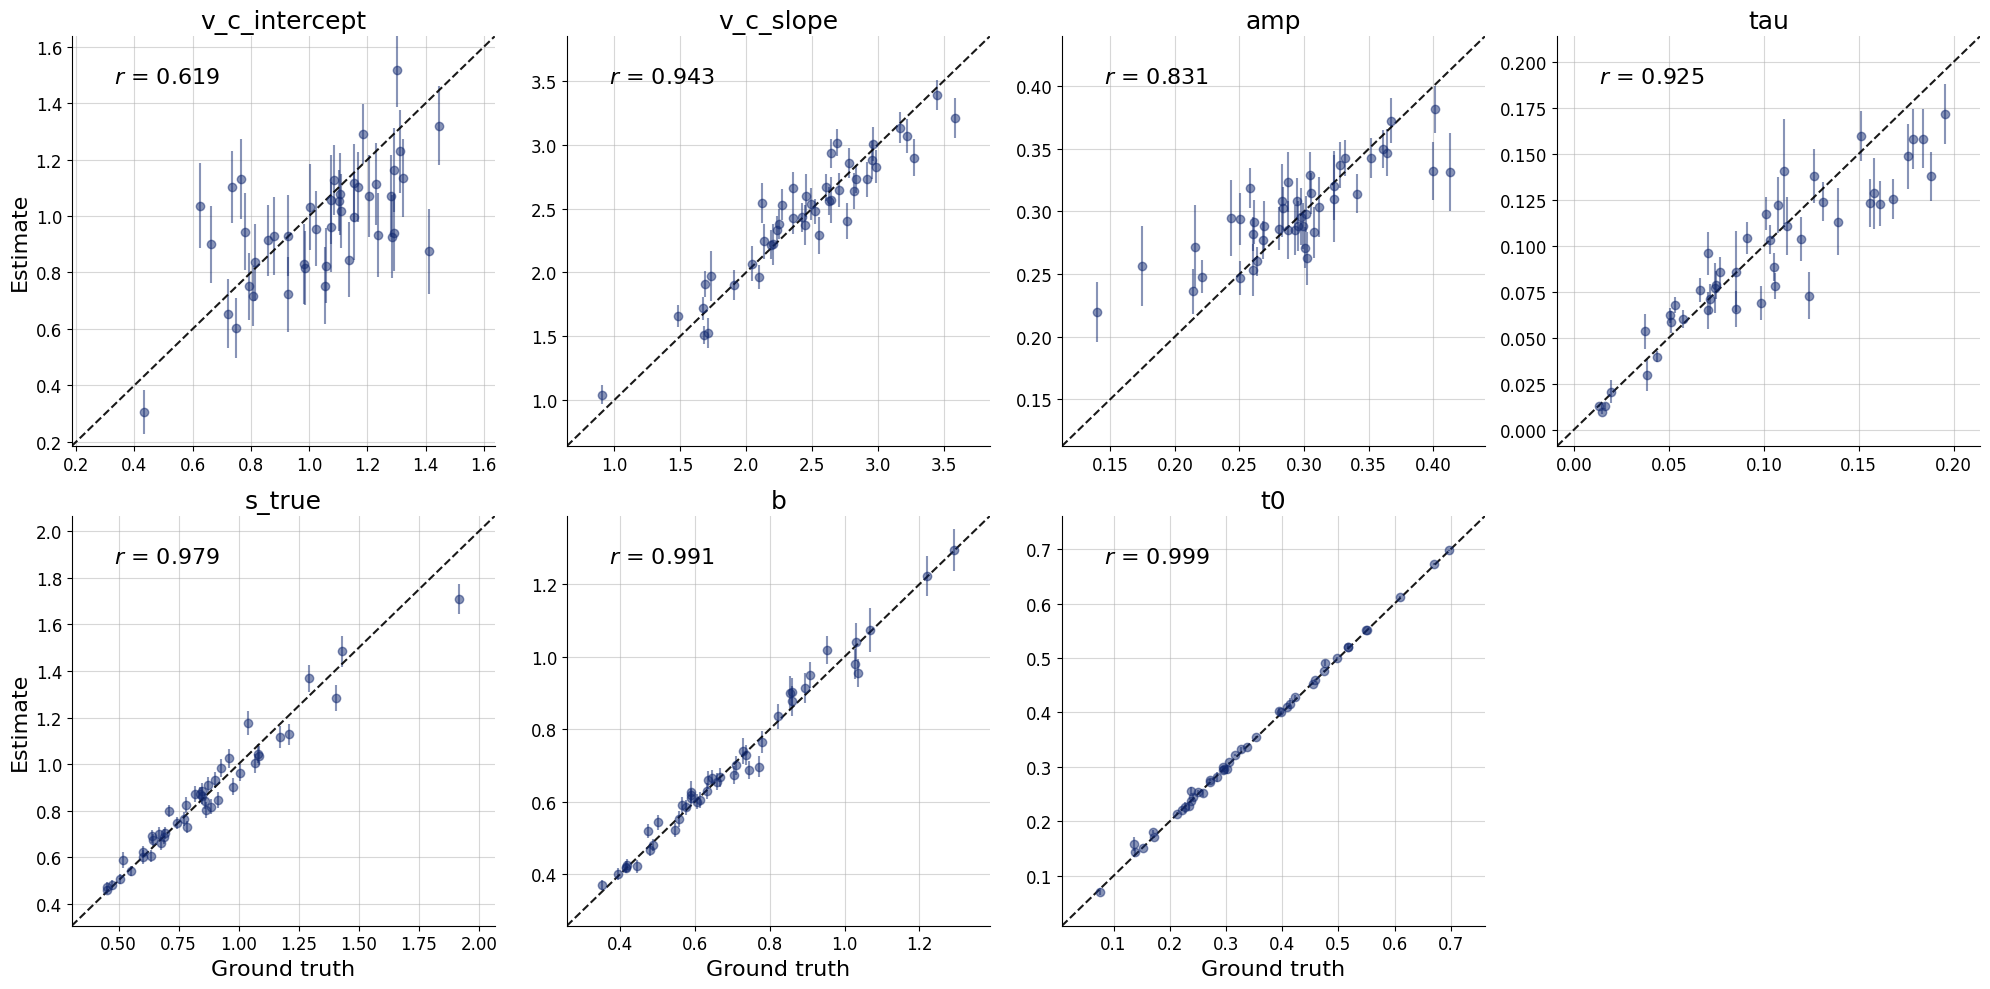

In [49]:
_ = bf.diagnostics.recovery(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names)
plt.savefig("parameter_recovery/crdm_recovery_approx.png")

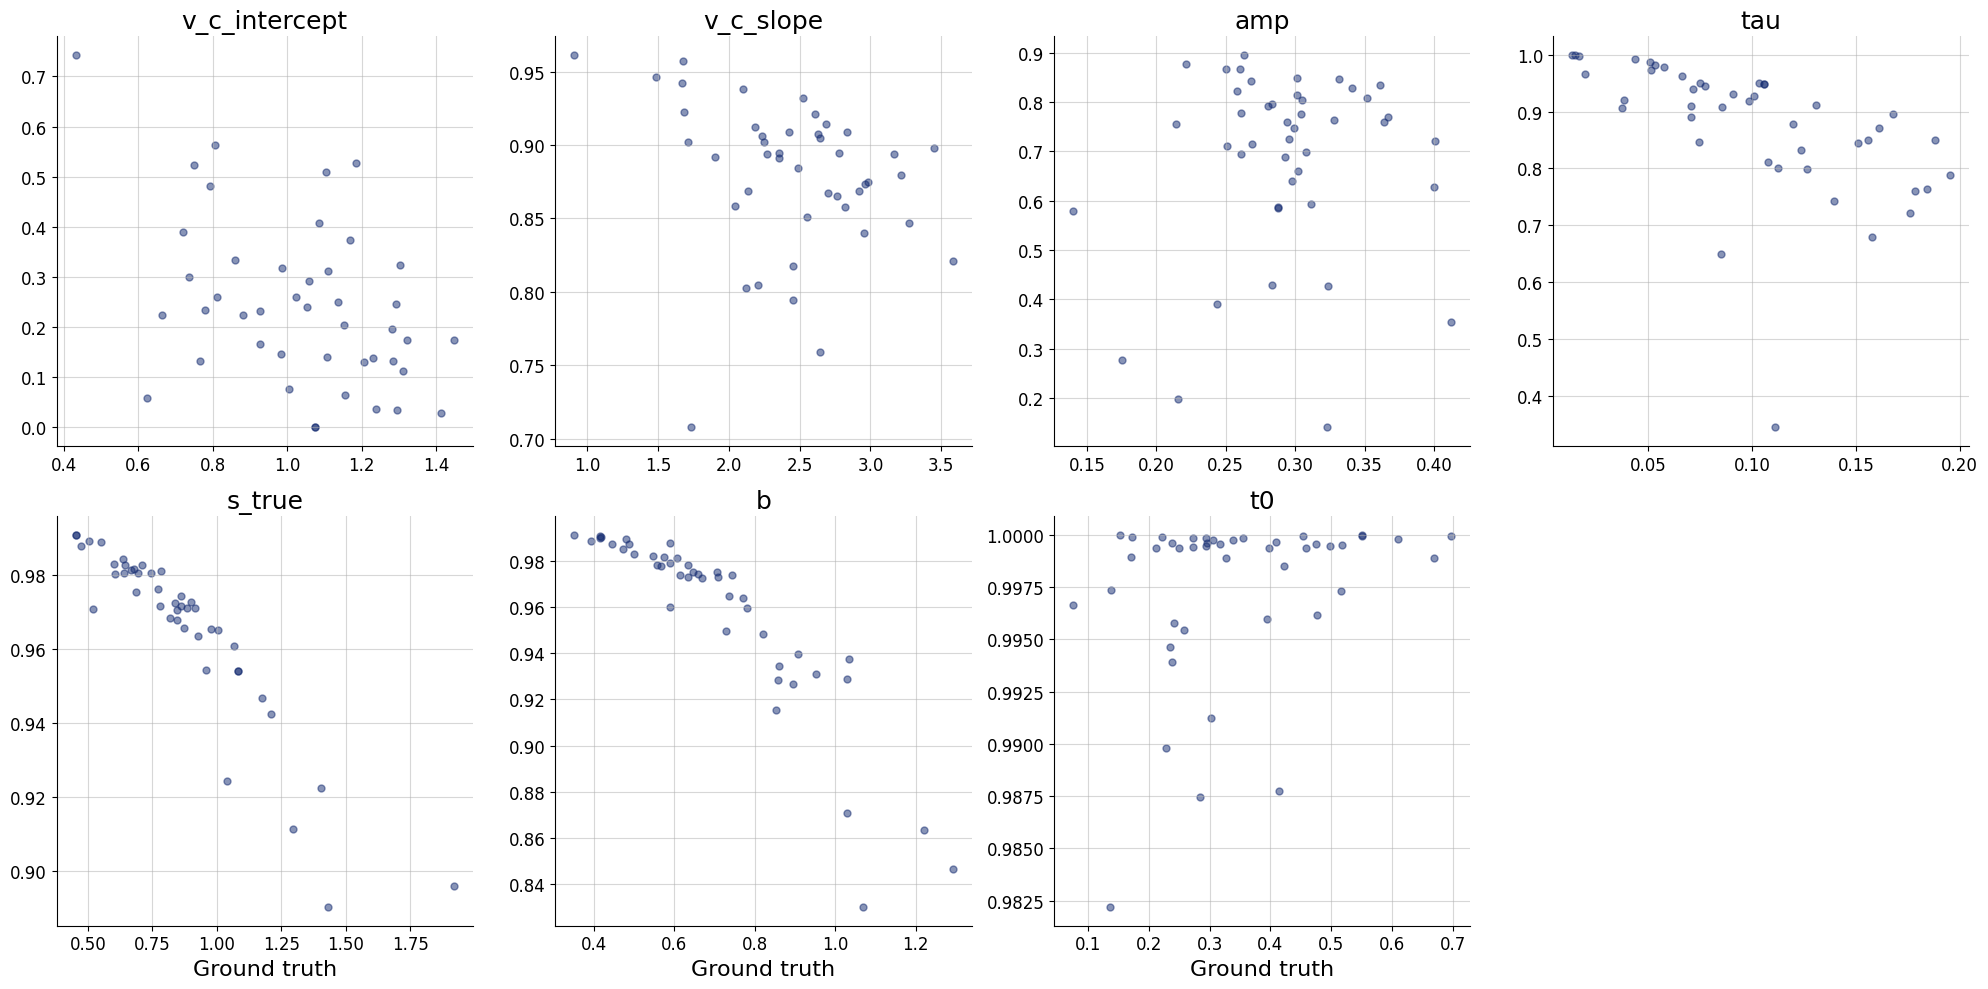

In [50]:
bf.diagnostics.plot_quantity(bf.diagnostics.posterior_contraction(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names, aggregation=None), prior_samples[is_converged_approx])
plt.savefig("parameter_recovery/crdm_pc_approx.png")

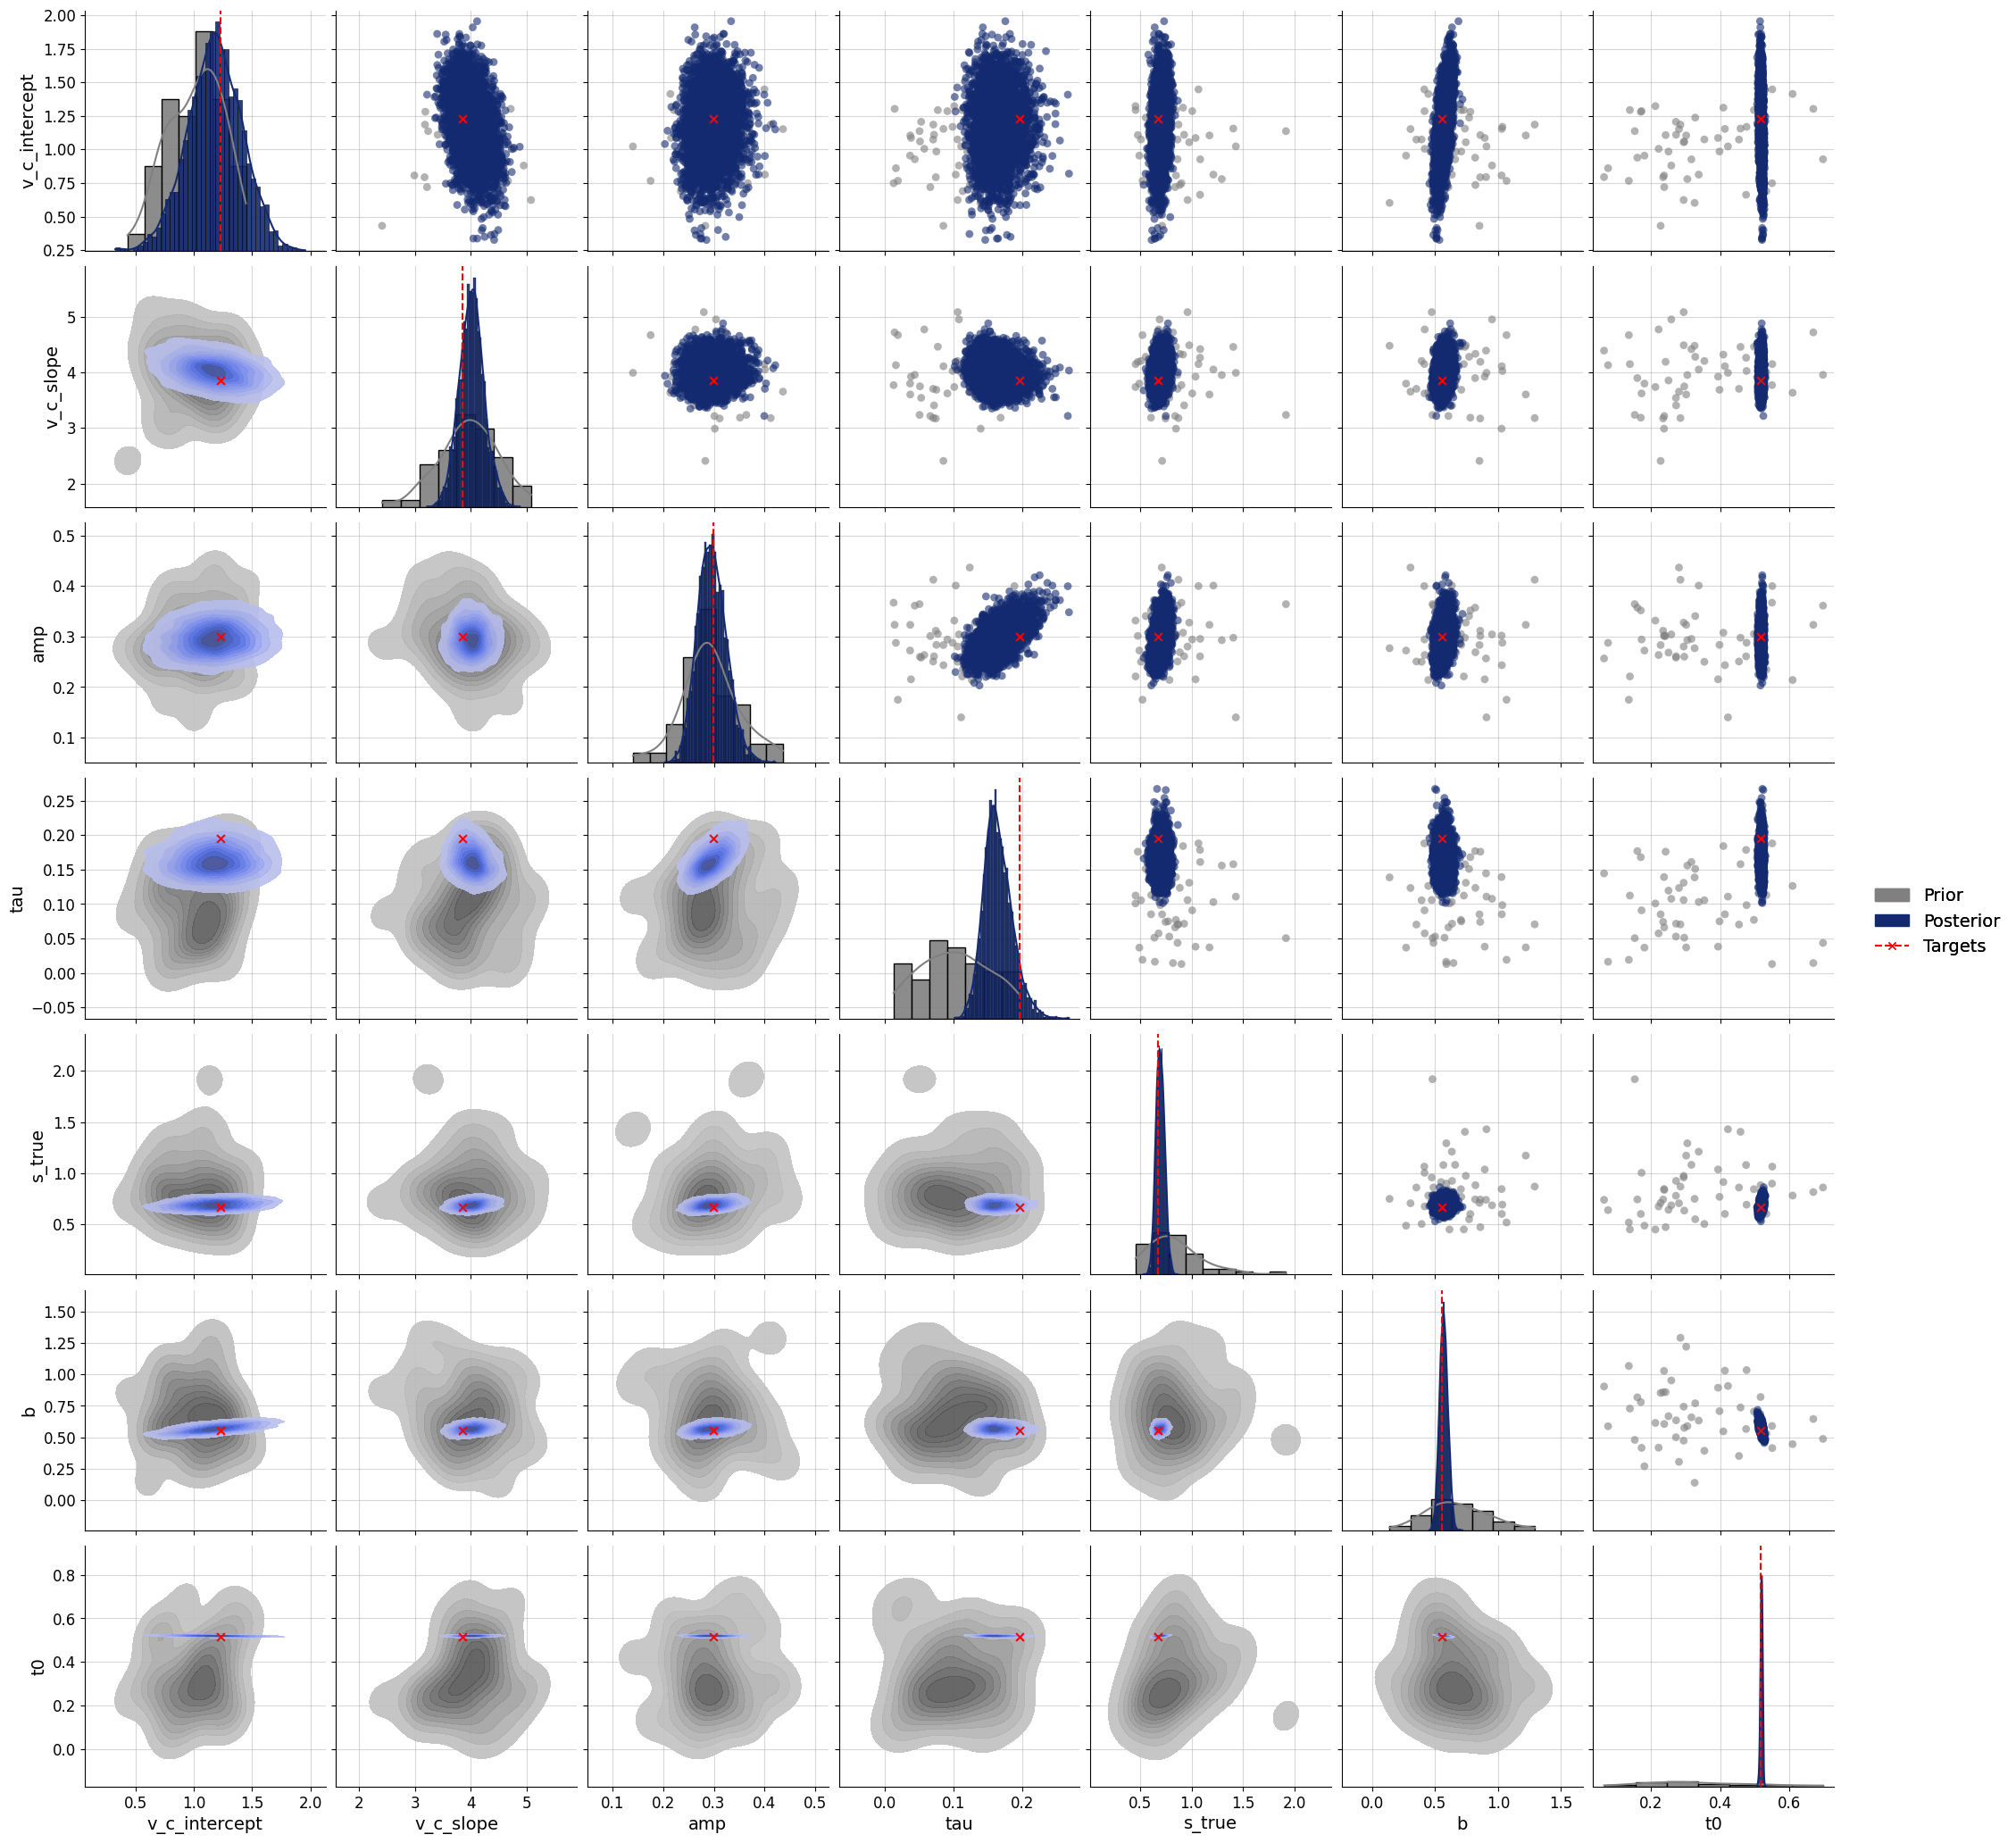

In [38]:
_ = bf.diagnostics.pairs_posterior(posterior_samples_approx[0], prior_samples[0], prior_samples, variable_names=param_names)